<a href="https://colab.research.google.com/github/monasolgi/SpongeBob/blob/main/titanic_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

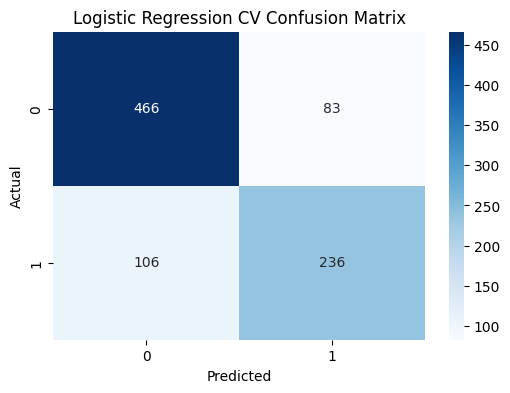

Random Forest CV scores: [0.75418994 0.79213483 0.85393258 0.7752809  0.83146067]
Random Forest mean CV score: 0.8013997865796247
Random Forest classification report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       549
           1       0.75      0.73      0.74       342

    accuracy                           0.80       891
   macro avg       0.79      0.79      0.79       891
weighted avg       0.80      0.80      0.80       891

Random Forest confusion matrix:
[[466  83]
 [ 94 248]]


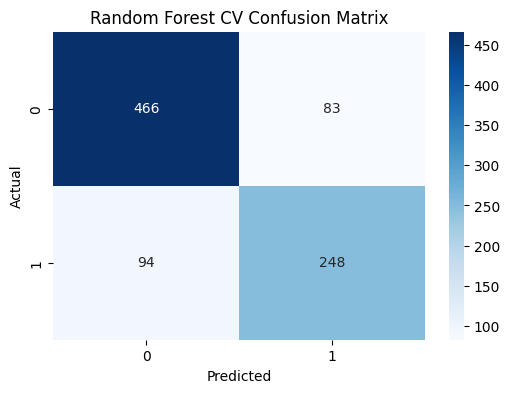

Model comparison:
Logistic Regression mean CV accuracy: 0.7879
Random Forest mean CV accuracy:       0.8014


In [ ]:
# ============================================================
# Titanic Project — Classification Practice
# Goal: Predict Survived using basic preprocessing + ML models
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# 1. Load data
# ============================================================

data = pd.read_csv("/content/train.csv")

print(data.head())
print(data.isna().sum())


# ============================================================
# 2. Cleaning + Feature Engineering
# ============================================================

data_clean = data.copy()

# Drop columns not used in this basic version:
# Name, Ticket, Cabin are text/high-missing-value columns.
# PassengerId is only an identifier, not useful for prediction.
data_clean = data_clean.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"])

# Fill missing Age with mean age.
# Simple baseline method; later we can improve this.
data_clean["Age"] = data_clean["Age"].fillna(data_clean["Age"].mean())

# Fill missing Embarked with most common value.
data_clean["Embarked"] = data_clean["Embarked"].fillna(data_clean["Embarked"].mode()[0])

# Convert Sex from text to numbers:
# male = 0, female = 1
data_clean["Sex"] = data_clean["Sex"].map({"male": 0, "female": 1})

# Create family size feature:
# +1 means we include the passenger themself.
data_clean["Family_size"] = data_clean["SibSp"] + data_clean["Parch"] + 1

# Drop original family columns after creating Family_size.
data_clean = data_clean.drop(columns=["SibSp", "Parch"])

# One-hot encode Embarked.
# drop_first=True removes one dummy column to avoid redundant information.
data_clean = pd.get_dummies(
    data_clean,
    columns=["Embarked"],
    drop_first=True
)

print(data_clean.info())
print(data_clean.isna().sum())


# ============================================================
# 3. Define features X and target y
# ============================================================

X = data_clean.drop(columns=["Survived"])
y = data_clean["Survived"]

print(X.head())
print(y.head())


# ============================================================
# 4. Manual train/validation split
# Purpose: learn the basic ML workflow manually
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression needs scaling because it is sensitive to feature scale.
scaler = StandardScaler()

# Fit scaler only on training data to avoid data leakage.
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predict validation data
val_predictions = lr_model.predict(X_val_scaled)

# Evaluate manual split
val_accuracy = accuracy_score(y_val, val_predictions)
val_cm = confusion_matrix(y_val, val_predictions)

print("Manual validation accuracy:", val_accuracy)
print("Manual validation confusion matrix:")
print(val_cm)


# ============================================================
# 5. Cross-validation with Logistic Regression
# Purpose: more reliable evaluation than one train/val split
# ============================================================

# Pipeline keeps scaling inside cross-validation.
  # For each fold:
    # 1. scaler fits only on training fold
    # 2. model trains on training fold
    # 3. model predicts validation fold
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5
)

# cross_val_predict gives one out-of-fold prediction for each row.
# Useful for confusion matrix and classification report.
lr_predictions_cv = cross_val_predict(
    lr_pipeline,
    X,
    y,
    cv=5
)

lr_cm_cv = confusion_matrix(y, lr_predictions_cv)

print("Logistic Regression CV scores:", lr_scores)
print("Logistic Regression mean CV score:", lr_scores.mean())

print("Logistic Regression classification report:")
print(classification_report(y, lr_predictions_cv))


# Plot Logistic Regression confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    lr_cm_cv,
    annot=True,     # show numbers inside cells
    fmt="d",        # integer format because confusion matrix has counts
    cmap="Blues"    # color theme
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression CV Confusion Matrix")
plt.show()


# ============================================================
# 6. Cross-validation with Random Forest
# Purpose: compare Logistic Regression with a non-linear model
# ============================================================

# Random Forest does not need scaling because it is tree-based.
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    random_state=42     # reproducible result
)

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

rf_predictions_cv = cross_val_predict(
    rf_model,
    X,
    y,
    cv=5
)

rf_cm_cv = confusion_matrix(y, rf_predictions_cv)

print("Random Forest CV scores:", rf_scores)
print("Random Forest mean CV score:", rf_scores.mean())

print("Random Forest classification report:")
print(classification_report(y, rf_predictions_cv))

print("Random Forest confusion matrix:")
print(rf_cm_cv)


# Plot Random Forest confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    rf_cm_cv,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest CV Confusion Matrix")
plt.show()


# ============================================================
# 7. Quick comparison
# ============================================================

print("Model comparison:")
print(f"Logistic Regression mean CV accuracy: {lr_scores.mean():.4f}")
print(f"Random Forest mean CV accuracy:       {rf_scores.mean():.4f}")


# ============================================================
# 8. Load test data
# ============================================================
test_data=pd.read_csv('/content/test.csv')

In [ ]:
# ============================================================
# 8. Load test data
# ============================================================
test_data=pd.read_csv('/content/test.csv')
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
